In [1]:
# --- Environment Setup ---
import os
from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Project root configuration
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CHE1148/project_code/CHE1148_Defect_Detecting")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project root not found: {PROJECT_ROOT}")

os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab_Notebooks/CHE1148/project_code/CHE1148_Defect_Detecting


In [2]:
import copy
import hashlib
import json
import math
import os
import random
from collections import defaultdict
from pathlib import Path
from typing import Any, Callable, Dict, Iterator, List, Optional, Tuple, cast

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import tqdm
from sklearn.metrics import ConfusionMatrixDisplay, average_precision_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import torchinfo
except ImportError:
    torchinfo = None

try:
    import torch_directml  # type: ignore
except ImportError:
    torch_directml = None

try:
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz
except ImportError:
    IntegratedGradients = None
    viz = None


In [3]:
# --- Global Path and Hardware Configuration ---
import torch
import random
import numpy as np
import os
from pathlib import Path
from typing import Optional, cast
import pandas as pd

IN_COLAB = True
ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/CHE1148/project_code/CHE1148_Defect_Detecting")
DATA_ROOT = ROOT / "data"

if not ROOT.exists():
    raise FileNotFoundError(f"Project root not found: {ROOT}")
if not DATA_ROOT.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

os.chdir(ROOT)

# Data directory structure
RAW = DATA_ROOT / "raw" / "textile"
PROCESSED = DATA_ROOT / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = PROCESSED / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# File path definitions
TRAIN_H5, TRAIN_CSV = RAW / "train64.h5", RAW / "train64.csv"
TEST_H5, TEST_CSV = RAW / "test64.h5", RAW / "test64.csv"
OUT_H5, OUT_CSV = PROCESSED / "full64.h5", PROCESSED / "full64.csv"
TRAIN_SPLIT_CSV = PROCESSED / "train_split.csv"
VAL_SPLIT_CSV = PROCESSED / "val_split.csv"
TEST_SPLIT_CSV = PROCESSED / "test_split.csv"

# Path utilities
def _require_file(path: Path) -> None:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

def _normalize_label(x) -> str:
    return str(x).strip()

def print_class_counts(df: pd.DataFrame, title: str) -> None:
    if "indication_type" not in df.columns:
        return
    vc = df["indication_type"].astype(str).str.strip().value_counts()
    print(f"\n[{title}] total_images={len(df)}")
    for k, v in vc.items():
        print(f"  {k}: {v}")

# Device and Runtime info
REQUIRE_CUDA = True
def select_device(require_cuda: bool = False):
    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        return torch.device("cuda"), f"cuda ({torch.cuda.get_device_name(0)})"
    if require_cuda: raise RuntimeError("CUDA unavailable")
    return torch.device("cpu"), "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device, device_name = select_device(require_cuda=REQUIRE_CUDA)
set_seed(42)
print(f"Using device: {device_name}")

Using device: cuda (NVIDIA L4)


In [4]:
# --- Global Training Configuration ---
FULL_CLASSES = ["good", "color", "cut", "hole", "thread", "metal_contamination"]

TRAIN_CFG = {
    "batch": 2048,
    "epochs": 30,
    "patience": 5,
    "num_workers": 4,
}

# --- Global Optimizer Configuration ---
OPTIM_CFG = {
    "name": "adam",
    "lr": 0.001,
    "foreach": False,
}

BASELINE_SCENARIO = "all_training"

# --- Global Evaluation Configuration ---
EVAL_CFG = {
    "f1_average": "macro",
    "auprc_average": "macro",
    "zero_division": 0,
    "early_stop_metric": "f1",
    "early_stop_mode": "max",
}

In [5]:
# --- Global Split Scenarios ---
SPLIT_SCENARIOS = {
    "all_training": {
        "defect_classes": FULL_CLASSES,
        "train_size": 47843,
        "defect_frac": 0.0,
        "desc": "All available deduplicated training data",
    },
    "fifty_fifty": {
        "defect_classes": FULL_CLASSES,
        "train_size": 20000,
        "defect_frac": 0.10,
        "desc": "50% good, 50% defects (evenly distributed)",
    },
    "exclude_two_classes": {
        "defect_classes": ["good", "color", "cut", "hole"],
        "train_size": 20000,
        "defect_frac": 0.0,
        "desc": "Exclude thread and metal_contamination classes",
    },
    "imbalanced": {
        "defect_classes": FULL_CLASSES,
        "train_size": 20000,
        "defect_frac": 0.02,
        "desc": "Strong class imbalance toward good samples",
    },
}

# Baseline CNN uses the default all_training scenario
BASELINE_SPLIT_CFG = SPLIT_SCENARIOS[BASELINE_SCENARIO]

for name, split_cfg in SPLIT_SCENARIOS.items():
    print(f"{name}: {split_cfg['desc']}")

all_training: All available deduplicated training data
fifty_fifty: 50% good, 50% defects (evenly distributed)
exclude_two_classes: Exclude thread and metal_contamination classes
imbalanced: Strong class imbalance toward good samples


In [6]:
# --- Dataset Merging Logic ---
def merge_data() -> None:
    """Merges raw train/test H5 and CSV files into a unified dataset."""
    if OUT_H5.exists() and OUT_CSV.exists():
        print("Dataset already merged.")
        return

    _require_file(TRAIN_CSV); _require_file(TEST_CSV)
    _require_file(TRAIN_H5); _require_file(TEST_H5)

    df_train = pd.read_csv(TRAIN_CSV)
    df_test = pd.read_csv(TEST_CSV)
    df_train["original_split"], df_test["original_split"] = "train", "test"

    full_df = pd.concat([df_train, df_test], ignore_index=True)
    full_df.to_csv(OUT_CSV, index=False)

    with h5py.File(OUT_H5, "w") as f_out:
        with h5py.File(TRAIN_H5, "r") as f_tr, h5py.File(TEST_H5, "r") as f_te:
            tr_imgs, te_imgs = f_tr["images"], f_te["images"]
            dset = f_out.create_dataset("images", shape=(len(tr_imgs)+len(te_imgs), *tr_imgs.shape[1:]), dtype="f")
            dset[:len(tr_imgs)] = tr_imgs[:]
            dset[len(tr_imgs):] = te_imgs[:]
    print(f"Merged data saved to: {OUT_H5}")

In [7]:
# --- Duplicate and Leakage Analysis ---
def get_h5_hashes(h5_path: Path, total_images: int, chunk_size: int = 5000) -> List[str]:
    """Generates MD5 fingerprints for images in H5 file chunks."""
    hashes = [""] * total_images
    with h5py.File(h5_path, "r") as f:
        imgs = f["images"]
        for start in range(0, total_images, chunk_size):
            end = min(start + chunk_size, total_images)
            chunk = imgs[start:end]
            for i, img in enumerate(chunk):
                hashes[start + i] = hashlib.md5(img.tobytes()).hexdigest()
    return hashes

def analyze_duplicates() -> List[str]:
    """Identifies duplicate images and checks for split leakage."""
    df = pd.read_csv(OUT_CSV)
    with h5py.File(OUT_H5, "r") as f:
        total = int(f["images"].shape[0])

    all_hashes = get_h5_hashes(OUT_H5, total)
    hash_map = defaultdict(list)
    for idx, h in enumerate(all_hashes): hash_map[h].append(idx)

    dups = {h: idxs for h, idxs in hash_map.items() if len(idxs) > 1}
    if dups:
        dup_indices = [i for idxs in dups.values() for i in idxs]
        report_df = df.iloc[dup_indices].copy()
        report_df["md5"] = [all_hashes[i] for i in dup_indices]
        report_df.to_csv(PROCESSED / "duplicates_report.csv", index=False)

        # Check for MD5 appearing in both train and test
        leakage = report_df.groupby("md5")["original_split"].nunique()
        print("[WARNING] Leakage detected!" if (leakage > 1).any() else "[SAFE] No split leakage.")
    return all_hashes

In [8]:

# ## 4. Split Generation (Dedup per original split + Stratified Train/Val)

def create_clean_split(all_hashes: List[str], included_classes: List[str], train_size: int, defect_frac: float) -> None:
    """
    Remove internal duplicates within each original split and generate Train/Val/Test CSVs.
    Remove requested classes from training set before splitting into final train and validation sets.

    Outputs:
      - data/processed/train_split.csv
      - data/processed/val_split.csv
      - data/processed/test_split.csv
    """
    df = pd.read_csv(OUT_CSV).copy()
    df["abs_ptr"] = range(len(df))  # pointer into full64.h5
    df["md5"] = all_hashes
    df["indication_type"] = df["indication_type"].astype(str).str.strip()

    tr_df_raw = df[df["original_split"] == "train"].copy()
    te_df_raw = df[df["original_split"] == "test"].copy()

    # Deduplicate within each portion
    tr_before, te_before = len(tr_df_raw), len(te_df_raw)
    tr_df = tr_df_raw.drop_duplicates(subset="md5", keep="first")
    te_df = te_df_raw.drop_duplicates(subset="md5", keep="first")
    tr_removed, te_removed = tr_before - len(tr_df), te_before - len(te_df)
    total_removed = tr_removed + te_removed

    print(f"Duplicates removed (within split): train={tr_removed}, test={te_removed}, total={total_removed}")

    # Keep only requested classes in training dataframe
    tr_df = tr_df[tr_df["indication_type"].isin(included_classes)].copy()

    # Sample desired fraction profile
    reduced_tr_df = reduce_training_set(tr_df, included_classes, train_size, defect_frac)
    reduced_tr_df = reduced_tr_df.sample(frac=1, random_state=42).reset_index(drop=True)

    split_col = "index" if "index" in reduced_tr_df.columns else "abs_ptr"

    # Stratified split (Train -> Train/Val) on unique sample key
    unique_df = reduced_tr_df.drop_duplicates(split_col)[[split_col, "indication_type"]].copy()
    label_counts = unique_df["indication_type"].value_counts()
    use_stratify = (label_counts.min() >= 2) and (label_counts.shape[0] > 1)
    stratify_labels = unique_df["indication_type"] if use_stratify else None
    if not use_stratify:
        print("[WARN] Stratified split disabled (insufficient per-class samples).")

    train_idx, val_idx = train_test_split(
        unique_df[split_col],
        test_size=0.1,
        random_state=42,
        stratify=stratify_labels,
    )

    df_train = reduced_tr_df[reduced_tr_df[split_col].isin(train_idx)].sample(frac=1, random_state=42)
    df_val = reduced_tr_df[reduced_tr_df[split_col].isin(val_idx)].sample(frac=1, random_state=42)

    train_path = TRAIN_SPLIT_CSV
    val_path = VAL_SPLIT_CSV
    test_path = TEST_SPLIT_CSV

    df_train.to_csv(train_path, index=False)
    df_val.to_csv(val_path, index=False)
    te_df.to_csv(test_path, index=False)

    print(f"Datasets finalized: Train({len(df_train)}), Val({len(df_val)}), Test({len(te_df)})")

    # Requested reporting
    print_class_counts(df, "FULL (merged)")
    print_class_counts(tr_df_raw, "ORIG TRAIN (raw)")
    print_class_counts(te_df_raw, "ORIG TEST (raw)")
    print_class_counts(tr_df, "ORIG TRAIN (deduped)")
    print_class_counts(te_df, "ORIG TEST (deduped)")
    print_class_counts(df_train, "TRAIN SPLIT")
    print_class_counts(df_val, "VAL SPLIT")
    print_class_counts(te_df, "TEST SPLIT")


def reduce_training_set(dedup_df, included_classes: List[str], training_size: int, defect_frac: float):
    # Use all deduplicated rows when defect_frac is 0.
    if defect_frac == 0:
        return dedup_df

    if len(included_classes) < 2:
        n = min(training_size, len(dedup_df))
        return dedup_df.sample(n=n, random_state=42)

    # defect_frac means per-defect-class fraction w.r.t. training_size
    num_defect_samples = math.floor(training_size * defect_frac)
    num_good_samples = training_size - num_defect_samples * (len(included_classes) - 1)

    if num_good_samples <= 0:
        raise ValueError(
            "Invalid training_size/defect_frac combination: non-positive good sample count. "
            f"training_size={training_size}, defect_frac={defect_frac}, classes={len(included_classes)}"
        )

    sampled_parts = []

    # sample defects
    for cls_name in included_classes[1:]:
        holder_df = dedup_df.loc[dedup_df["indication_type"] == cls_name]
        n = min(num_defect_samples, len(holder_df))
        if n < num_defect_samples:
            print(f"[WARN] class={cls_name}: requested {num_defect_samples}, available {len(holder_df)}, using {n}")
        if n > 0:
            sampled_parts.append(holder_df.sample(n=n, random_state=42))

    # sample good
    good_df = dedup_df.loc[dedup_df["indication_type"] == included_classes[0]]
    n_good = min(num_good_samples, len(good_df))
    if n_good < num_good_samples:
        print(
            f"[WARN] class={included_classes[0]}: requested {num_good_samples}, available {len(good_df)}, using {n_good}")
    if n_good > 0:
        sampled_parts.append(good_df.sample(n=n_good, random_state=42))

    if not sampled_parts:
        raise ValueError("No samples selected. Please adjust training_size/defect_frac.")

    reduced_df = pd.concat(sampled_parts, ignore_index=True)
    return reduced_df


In [9]:
#
# ## 5. Label Map

LABEL_MAP_JSON = PROCESSED / "label_map.json"
EXPECTED_CLASSES = list(FULL_CLASSES)


def _validate_labels(observed: List[str], label_map: Dict[str, int]) -> None:
    unknown = sorted(set(observed) - set(label_map.keys()))
    if unknown:
        raise ValueError(
            "CSV contains unknown class names (not in label_map).\n"
            f"unknown_labels={unknown}\n"
            f"label_map_keys={sorted(label_map.keys())}"
        )


def build_label_map_from_full_csv(full_csv_path: Path) -> Dict[str, int]:
    '''
    Build a stable label map from labels present in the provided CSV.
    Order always follows EXPECTED_CLASSES.
    '''
    df = pd.read_csv(full_csv_path)
    observed = set(df["indication_type"].astype(str).str.strip().unique().tolist())

    unknown = sorted(observed - set(EXPECTED_CLASSES))
    if unknown:
        raise ValueError(
            "CSV contains labels outside EXPECTED_CLASSES.\n"
            f"unknown={unknown}\n"
            f"expected={EXPECTED_CLASSES}"
        )

    ordered_present = [name for name in EXPECTED_CLASSES if name in observed]
    if not ordered_present:
        raise ValueError("No valid labels found in CSV.")

    return {name: i for i, name in enumerate(ordered_present)}


def load_or_create_label_map(PASSED_PATH: Path) -> Dict[str, int]:
    label_map = build_label_map_from_full_csv(PASSED_PATH)
    LABEL_MAP_JSON.write_text(
        json.dumps(label_map, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return label_map


def validate_split_labels(csv_path: Path, label_map: Dict[str, int]) -> None:
    df = pd.read_csv(csv_path)
    observed = df["indication_type"].astype(str).str.strip().unique().tolist()
    _validate_labels([_normalize_label(x) for x in observed], label_map)


def validate_common_splits(label_map: Dict[str, int], include_test: bool = True) -> None:
    validate_split_labels(TRAIN_SPLIT_CSV, label_map)
    validate_split_labels(VAL_SPLIT_CSV, label_map)
    if include_test:
        validate_split_labels(TEST_SPLIT_CSV, label_map)


def make_split_datasets_and_loaders(label_map: Dict[str, int], batch_size: int):
    train_ds = TextileDataset(TRAIN_SPLIT_CSV, OUT_H5, label_map=label_map)
    val_ds = TextileDataset(VAL_SPLIT_CSV, OUT_H5, label_map=label_map)
    # Optimized with num_workers and pin_memory
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=TRAIN_CFG.get("num_workers", 0),
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        num_workers=TRAIN_CFG.get("num_workers", 0),
        pin_memory=True
    )
    return train_ds, val_ds, train_loader, val_loader


def make_filtered_test_dataset_and_loader(
    label_map: Dict[str, int],
    batch_size: int,
    split_tag: str,
):
    """Build a test loader filtered to classes present in the given label_map."""
    df_test = pd.read_csv(TEST_SPLIT_CSV).copy()
    df_test["indication_type"].astype(str).str.strip()
    allowed = set(label_map.keys())
    filtered = df_test[df_test["indication_type"].isin(allowed)].copy()

    filtered_csv = PROCESSED / f"test_split_filtered_{split_tag}.csv"
    filtered.to_csv(filtered_csv, index=False)

    test_ds = TextileDataset(filtered_csv, OUT_H5, label_map=label_map)
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        num_workers=TRAIN_CFG.get("num_workers", 0),
        pin_memory=True
    )
    return test_ds, test_loader, filtered_csv


def evaluate_loader(model: nn.Module, loader: DataLoader, device: torch.device):
    """Evaluate model on a dataloader using existing run_step() metrics logic."""
    dummy_opt = optim.SGD(model.parameters(), lr=0.0)
    criterion_eval = nn.CrossEntropyLoss()
    return run_step(model, loader, criterion_eval, dummy_opt, device, is_train=False)

In [20]:
# --- PyTorch Dataset and Model Architectures ---
class TextileDataset(Dataset):
    """Custom Dataset for reading 64x64 textile images from H5 via pointers."""
    def __init__(self, csv_path, h5_path, label_map, transform=None):
        self.df = pd.read_csv(csv_path)
        self.h5_path = str(h5_path)
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with h5py.File(self.h5_path, "r") as f:
            img = f["images"][int(row["abs_ptr"])]

        img_t = torch.from_numpy(img).float()

        # Standardize to (Channels, Height, Width)
        if img_t.ndim == 2:
            img_t = img_t.unsqueeze(0)
        elif img_t.ndim == 3 and img_t.shape[-1] == 1:
            # Convert (H, W, 1) to (1, H, W)
            img_t = img_t.permute(2, 0, 1)

        if img_t.max() > 1.0:
            img_t /= 255.0

        if self.transform:
            img_t = self.transform(img_t)

        label = self.label_map[_normalize_label(row["indication_type"])]
        return img_t, torch.tensor(label, dtype=torch.long)

class TextileBaselineCNN(nn.Module):
    """Three-layer CNN architecture for textile defect classification."""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 8 * 8, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

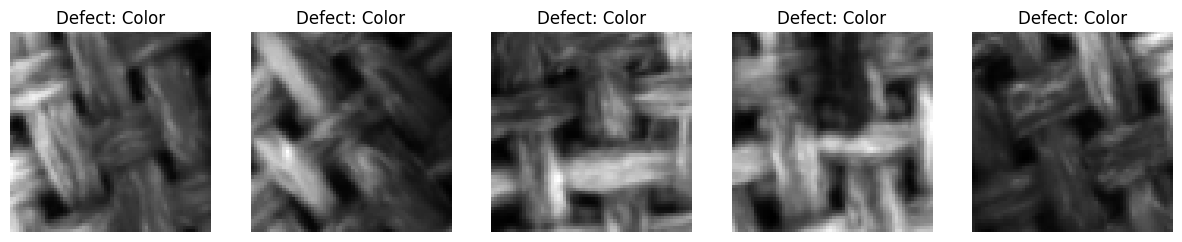

In [21]:

# Quick Visualization (Color Defect Samples)

def visualize_color_defects(dataset, label_map, num_samples=5):
    # Find the integer index for the 'color' class
    if "color" not in label_map:
        print("[INFO] 'color' class is not in current label_map. Skipping visualization.")
        return
    color_idx = label_map["color"]

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]

    found = 0
    for img, label in dataset:
        label_val = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_val == color_idx:
            # Reshape from (1, 64, 64) to (64, 64) for plotting
            axes[found].imshow(img.squeeze(), cmap="gray")
            axes[found].set_title("Defect: Color")
            axes[found].axis("off")
            found += 1
        if found == num_samples:
            break

    if found < num_samples:
        print(f"Only found {found} color samples.")
    plt.show()


# Optional quick demo: safe to run before/after training cells.
train_split_csv = TRAIN_SPLIT_CSV
if train_split_csv.exists():
    demo_label_map = load_or_create_label_map(train_split_csv)
    demo_train_ds = TextileDataset(train_split_csv, OUT_H5, label_map=demo_label_map)
    visualize_color_defects(demo_train_ds, demo_label_map)
else:
    print("[INFO] train_split.csv not found yet. Run split-generation/training cells first, then rerun this cell.")


In [22]:
# --- Training Utilities ---

class EarlyStopping:
    """Monitors a metric and stops training if it stops improving."""
    def __init__(self, patience=5, verbose=True, mode="min", metric_name="metric", min_delta=0.0):
        if mode not in {"min", "max"}: raise ValueError("mode must be 'min' or 'max'")
        self.patience, self.verbose, self.mode = patience, verbose, mode
        self.metric_name, self.min_delta = metric_name, min_delta
        self.counter, self.early_stop = 0, False
        self.best_score = float("inf") if mode == "min" else -float("inf")
        self.best_model_state = None

    def _is_improvement(self, score):
        """Checks if the current score improves upon the best recorded score."""
        if self.mode == "min": return score < (self.best_score - self.min_delta)
        return score > (self.best_score + self.min_delta)

    def __call__(self, score, model):
        """Updates early stopping status based on the latest validation score."""
        if self._is_improvement(score):
            self.best_score, self.counter = score, 0
            self.best_model_state = copy.deepcopy(model.state_dict())
            if self.verbose: print(f"Validation {self.metric_name} improved. Saving weights.")
        else:
            self.counter += 1
            if self.verbose: print(f"EarlyStopping counter: {self.counter} of {self.patience}")
            if self.counter >= self.patience: self.early_stop = True

def _compute_eval_metrics(y_true, y_pred, y_prob, num_classes):
    """Calculates Accuracy, F1-score, and AUPRC."""
    acc = 100.0 * (y_pred == y_true).sum() / max(len(y_true), 1)
    f1 = f1_score(y_true, y_pred, labels=list(range(num_classes)),
                  average=EVAL_CFG["f1_average"], zero_division=EVAL_CFG["zero_division"])

    y_true_bin = np.eye(num_classes)[y_true]
    try:
        auprc = average_precision_score(y_true_bin, y_prob, average=EVAL_CFG["auprc_average"])
    except:
        auprc = float("nan")
    return {"accuracy": float(acc), "f1": float(f1), "auprc": float(auprc)}

def _metric_to_str(v, digits=4):
    """Converts a numeric metric value to a formatted string, handling NaNs."""
    return "nan" if np.isnan(v) else f"{v:.{digits}f}"

def run_step(model, loader, criterion, optimizer, device, is_train=True):
    """Executes a single training or validation epoch across the provided loader."""
    model.train() if is_train else model.eval()
    total_loss, all_true, all_pred, all_prob = 0.0, [], [], []

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            all_true.append(labels.cpu().numpy())
            all_pred.append(outputs.argmax(dim=1).cpu().numpy())
            all_prob.append(torch.softmax(outputs, dim=1).detach().cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    if not all_true: return avg_loss, {"accuracy": 0.0, "f1": 0.0, "auprc": float("nan")}

    y_true, y_pred, y_prob = np.concatenate(all_true), np.concatenate(all_pred), np.concatenate(all_prob)
    return avg_loss, _compute_eval_metrics(y_true, y_pred, y_prob, y_prob.shape[1])

In [23]:

# ## 8. Main (Baseline CNN)
# This section uses shared settings from TRAIN_CFG and scenario `all_training`.


In [24]:
# Step 1: Build processed dataset and baseline split files
merge_data()
hashes = analyze_duplicates()
create_clean_split(hashes, BASELINE_SPLIT_CFG["defect_classes"], BASELINE_SPLIT_CFG["train_size"],
                   BASELINE_SPLIT_CFG["defect_frac"])


Dataset already merged.
[SAFE] No split leakage.
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(43058), Val(4785), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=43058
  good: 7200
  cut: 7192
  color: 7192
  hole: 7182
  thread: 7160
  metal_contamination: 7132

[VAL SPLIT] total_i

In [25]:
# Step 2: Build and validate label map for baseline split
label_map = load_or_create_label_map(OUT_CSV)
validate_common_splits(label_map, include_test=True)
print("\nlabel_map:", label_map)



label_map: {'good': 0, 'color': 1, 'cut': 2, 'hole': 3, 'thread': 4, 'metal_contamination': 5}


In [26]:
# Step 3: Create datasets and dataloaders
train_ds, val_ds, train_loader, val_loader = make_split_datasets_and_loaders(label_map, TRAIN_CFG["batch"])


In [27]:
# Step 4: Initialize baseline CNN training components
import subprocess
import sys

# --- 4.1 Dependency Check ---
try:
    import torchinfo
except ImportError:
    print("[INFO] torchinfo not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchinfo"])
    import torchinfo

# --- 4.2 Model Setup ---
model = TextileBaselineCNN(num_classes=len(label_map)).to(device)
print("Baseline CNN Model Summary for Textile Defect Detection:")

dummy_input = torch.randn(TRAIN_CFG["batch"], 1, 64, 64).to(device)
summary_obj = torchinfo.summary(
    model,
    input_data=dummy_input,
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    verbose=0,
)
print(summary_obj)

# --- 4.3 Training Objects ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=OPTIM_CFG["lr"], foreach=OPTIM_CFG["foreach"])
early_stop = EarlyStopping(
    patience=TRAIN_CFG["patience"],
    verbose=True,
    mode=EVAL_CFG["early_stop_mode"],
    metric_name=EVAL_CFG["early_stop_metric"],
)

Baseline CNN Model Summary for Textile Defect Detection:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
TextileBaselineCNN                       [2048, 1, 64, 64]         [2048, 6]                 --                        --
├─Sequential: 1-1                        [2048, 1, 64, 64]         [2048, 128, 8, 8]         --                        --
│    └─Conv2d: 2-1                       [2048, 1, 64, 64]         [2048, 32, 64, 64]        320                       [3, 3]
│    └─BatchNorm2d: 2-2                  [2048, 32, 64, 64]        [2048, 32, 64, 64]        64                        --
│    └─ReLU: 2-3                         [2048, 32, 64, 64]        [2048, 32, 64, 64]        --                        --
│    └─MaxPool2d: 2-4                    [2048, 32, 64, 64]        [2048, 32, 32, 32]        --                        2
│    └─Conv2d: 2-5                       [2048, 32, 32, 32]        [2048, 64

In [28]:
# Step 5: Train baseline CNN and save best checkpoint
from tqdm.notebook import tqdm

print(f"\nStarting training on: {device}")

# Initialize progress bar for Colab notebook
pbar = tqdm(range(TRAIN_CFG["epochs"]), desc="Baseline CNN")

# Disable verbose output for early stopping as requested
early_stop.verbose = False

history = []

for epoch in pbar:
    # Run training and validation steps
    t_loss, t_metrics = run_step(model, train_loader, criterion, optimizer, device, is_train=True)
    v_loss, v_metrics = run_step(model, val_loader, criterion, optimizer, device, is_train=False)

    # Store history for final reporting
    history.append({
        "epoch": epoch + 1,
        "f1": v_metrics["f1"],
        "auprc": v_metrics["auprc"],
        "accuracy": v_metrics["accuracy"]
    })

    # Update progress bar with metrics
    pbar.set_postfix({
        "v_f1": _metric_to_str(v_metrics["f1"]),
        "v_acc": _metric_to_str(v_metrics["accuracy"], digits=2),
        "v_loss": f"{v_loss:.4f}"
    })

    # Early stopping logic
    early_stop(v_metrics[EVAL_CFG["early_stop_metric"]], model)
    if early_stop.early_stop:
        pbar.write(f"Early stopping triggered at epoch {epoch + 1}")
        model.load_state_dict(early_stop.best_model_state)
        break

# Save final model
torch.save(model.state_dict(), "best_textile_baseline.pth")

# Find best performance stats
best_record = max(history, key=lambda x: x["f1"])

print("\n" + "="*40)
print("TRAINING COMPLETE")
print(f"Best Performance at Epoch: {best_record['epoch']}")
print(f"F1 Score: {best_record['f1']:.4f}")
print(f"AUPRC:    {best_record['auprc']:.4f}")
print(f"Accuracy: {best_record['accuracy']:.2f}%")
print(f"Final model saved to: best_textile_baseline.pth")
print("="*40)


Starting training on: cuda


Baseline CNN:   0%|          | 0/30 [00:00<?, ?it/s]

Early stopping triggered at epoch 27

TRAINING COMPLETE
Best Performance at Epoch: 22
F1 Score: 0.7767
AUPRC:    0.8648
Accuracy: 77.60%
Final model saved to: best_textile_baseline.pth


In [29]:

# Below contetn uses ResNet-18 Model
# And use 4 different`SPLIT_SCENARIOS` to see the influence from splitting strategy

In [30]:
class TextileResNet(nn.Module):
    def __init__(self, num_classes: int):
        super(TextileResNet, self).__init__()

        # Load pre-trained ResNet-18
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Adapt stem for 1x64x64 grayscale inputs
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)

        # Adapt output head for specific num_classes
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.model(x)

In [31]:
# Instantiate a preview ResNet (all-training scenario class count)
label_map_all = load_or_create_label_map(OUT_CSV)
model_preview = TextileResNet(len(label_map_all)).to(device)

print("ResNet-18 Model Summary for Textile Defect Detection:")
if torchinfo is not None:
    summary_obj = torchinfo.summary(
        model_preview,
        input_size=(TRAIN_CFG["batch"], 1, 64, 64),
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        verbose=0,
    )
    print(summary_obj)
else:
    print("[INFO] torchinfo not installed. Skipping model summary.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


ResNet-18 Model Summary for Textile Defect Detection:
Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
TextileResNet                                 [2048, 1, 64, 64]         [2048, 6]                 --                        --
├─ResNet: 1-1                                 [2048, 1, 64, 64]         [2048, 6]                 --                        --
│    └─Conv2d: 2-1                            [2048, 1, 64, 64]         [2048, 64, 64, 64]        576                       [3, 3]
│    └─BatchNorm2d: 2-2                       [2048, 64, 64, 64]        [2048, 64, 64, 64]        128                       --
│    └─ReLU: 2-3                              [2048, 64, 64, 64]        [2048, 64, 64, 64]        --                        --
│    └─MaxPool2d: 2-4                         [2048, 64, 64, 64]        [2048, 64, 32, 32]        --                        3
│    └─Sequential: 2-5                      

In [32]:
def prepare_resnet_split_and_loaders(split_name: str, split_cfg: Dict, train_cfg: Dict):
    create_clean_split(
        hashes,
        split_cfg["defect_classes"],
        split_cfg["train_size"],
        split_cfg["defect_frac"],
    )

    split_label_map = load_or_create_label_map(TRAIN_SPLIT_CSV)
    validate_common_splits(split_label_map, include_test=False)

    split_train_ds, split_val_ds, split_train_loader, split_val_loader = make_split_datasets_and_loaders(
        split_label_map, train_cfg["batch"]
    )
    split_test_ds, split_test_loader, split_test_csv = make_filtered_test_dataset_and_loader(
        split_label_map,
        train_cfg["batch"],
        split_tag=f"resnet_{split_name}",
    )

    return (
        split_label_map,
        split_train_ds,
        split_val_ds,
        split_test_ds,
        split_train_loader,
        split_val_loader,
        split_test_loader,
        split_test_csv,
    )


In [37]:
# --- ResNet Training and Scenario Evaluation ---
resnet_models, resnet_histories, resnet_label_maps, resnet_loaders = {}, {}, {}, {}
resnet_summary = []

for scenario_name, split_cfg in SPLIT_SCENARIOS.items():
    print(f"\n=== ResNet Scenario: {scenario_name} ===")

    # Setup data for current scenario
    res = prepare_resnet_split_and_loaders(scenario_name, split_cfg, TRAIN_CFG)
    split_label_map, split_train_ds, split_val_ds, split_test_ds, split_train_loader, split_val_loader, split_test_loader, split_test_csv = res

    # Initialize model and components
    model_curr = TextileResNet(num_classes=len(split_label_map)).to(device)
    optimizer_curr = optim.Adam(model_curr.parameters(), lr=OPTIM_CFG["lr"])
    criterion_curr = nn.CrossEntropyLoss()
    stopper_curr = EarlyStopping(patience=TRAIN_CFG["patience"], verbose=False, mode="max", metric_name="f1")

    history_curr = []
    pbar = tqdm(range(TRAIN_CFG["epochs"]), desc=f"ResNet {scenario_name}")

    for epoch in pbar:
        t_loss, t_met = run_step(model_curr, split_train_loader, criterion_curr, optimizer_curr, device, True)
        v_loss, v_met = run_step(model_curr, split_val_loader, criterion_curr, optimizer_curr, device, False)

        for split, loss, met in [("Train", t_loss, t_met), ("Val", v_loss, v_met)]:
            history_curr.append({"Epoch": epoch+1, "Split": split, "Loss": loss, "Accuracy": met["accuracy"], "F1": met["f1"], "AUPRC": met["auprc"]})

        pbar.set_postfix({"val_f1": _metric_to_str(v_met["f1"]), "val_acc": _metric_to_str(v_met["accuracy"], 2)})
        stopper_curr(v_met["f1"], model_curr)
        if stopper_curr.early_stop: break

    # Save and summarize
    if stopper_curr.best_model_state: model_curr.load_state_dict(stopper_curr.best_model_state)
    val_best = max([h for h in history_curr if h["Split"] == "Val"], key=lambda x: x["F1"])

    resnet_summary.append({"Model": "ResNet-18", "Scenario": scenario_name, "Best Epoch": val_best["Epoch"], "F1": val_best["F1"], "AUPRC": val_best["AUPRC"], "Accuracy": val_best["Accuracy"]})

    # Store results and loaders for evaluation/visualization
    resnet_models[scenario_name] = model_curr
    resnet_histories[scenario_name] = history_curr
    resnet_label_maps[scenario_name] = split_label_map
    resnet_loaders[scenario_name] = {
        "test_loader": split_test_loader,
        "test_ds": split_test_ds,
        "test_csv": split_test_csv
    }


=== ResNet Scenario: all_training ===
Duplicates removed (within split): train=157, test=234, total=391
Datasets finalized: Train(43058), Val(4785), Test(47766)

[FULL (merged)] total_images=96000
  good: 16000
  color: 16000
  cut: 16000
  hole: 16000
  metal_contamination: 16000
  thread: 16000

[ORIG TRAIN (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TEST (raw)] total_images=48000
  good: 8000
  color: 8000
  cut: 8000
  hole: 8000
  metal_contamination: 8000
  thread: 8000

[ORIG TRAIN (deduped)] total_images=47843
  good: 8000
  color: 7991
  cut: 7991
  hole: 7980
  thread: 7956
  metal_contamination: 7925

[ORIG TEST (deduped)] total_images=47766
  good: 8000
  cut: 7984
  hole: 7979
  thread: 7974
  color: 7945
  metal_contamination: 7884

[TRAIN SPLIT] total_images=43058
  good: 7200
  cut: 7192
  color: 7192
  hole: 7182
  thread: 7160
  metal_contamination: 7132

[VAL SPLIT] total_images=4785

ResNet all_training:   0%|          | 0/30 [00:00<?, ?it/s]


KeyboardInterrupt



In [35]:
# --- Test-set evaluation (Baseline CNN + ResNet scenarios) ---
# This cell provides a consolidated view of final model performance on unseen test data.
test_eval_rows = []

if {"model", "label_map", "device"}.issubset(globals()):
    baseline_test_ds, baseline_test_loader, baseline_test_csv = make_filtered_test_dataset_and_loader(
        label_map,
        TRAIN_CFG["batch"],
        split_tag="baseline_cnn",
    )
    baseline_test_loss, baseline_test_metrics = evaluate_loader(model, baseline_test_loader, device)
    test_eval_rows.append(
        {
            "model": "baseline_cnn",
            "scenario": BASELINE_SCENARIO,
            "n_samples": len(baseline_test_ds),
            "loss": baseline_test_loss,
            "accuracy": baseline_test_metrics["accuracy"],
            "f1": baseline_test_metrics["f1"],
            "auprc": baseline_test_metrics["auprc"],
            "test_csv": str(baseline_test_csv),
        }
    )
else:
    print("[WARN] Baseline CNN globals not ready. Skipping baseline test evaluation.")

if {"resnet_models", "resnet_label_maps", "resnet_loaders", "device"}.issubset(globals()):
    for scenario_name in SPLIT_SCENARIOS.keys():
        if scenario_name not in resnet_models:
            continue

        split_test_loader = resnet_loaders[scenario_name]["test_loader"]
        split_test_ds = resnet_loaders[scenario_name]["test_ds"]
        split_test_csv = resnet_loaders[scenario_name]["test_csv"]
        split_test_loss, split_test_metrics = evaluate_loader(
            resnet_models[scenario_name],
            split_test_loader,
            device,
        )
        test_eval_rows.append(
            {
                "model": "resnet18",
                "scenario": scenario_name,
                "n_samples": len(split_test_ds),
                "loss": split_test_loss,
                "accuracy": split_test_metrics["accuracy"],
                "f1": split_test_metrics["f1"],
                "auprc": split_test_metrics["auprc"],
                "test_csv": str(split_test_csv),
            }
        )
else:
    print("[WARN] ResNet globals not ready. Skipping ResNet test evaluation.")

if test_eval_rows:
    test_eval_results = pd.DataFrame(test_eval_rows)
    print("\n=== Final Test-set Performance Summary ===")
    display(test_eval_results[["model", "scenario", "n_samples", "accuracy", "f1", "auprc", "loss"]])
else:
    print("[WARN] No test evaluation results produced.")

KeyError: 'all_training'

In [ ]:
# --- 1. PERFORMANCE PLOT (all_training scenario only) ---
def plot_history(results_list, save_path=None, dpi=280):
    history_df = pd.DataFrame(results_list)
    metrics = [m for m in ["Accuracy", "F1", "AUPRC", "Loss"] if m in history_df.columns]
    if not metrics:
        print("[INFO] No plottable metrics found in history.")
        return

    line_colors = {"Train": "#0b3c5d", "Val": "#8a6f00"}

    with plt.rc_context({
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "savefig.facecolor": "#ffffff",
        "savefig.edgecolor": "#ffffff",
        "savefig.transparent": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "axes.edgecolor": "#1f1f1f",
        "xtick.color": "#111111",
        "ytick.color": "#111111",
        "grid.color": "#c6c6c6",
        "grid.alpha": 0.65,
        "grid.linestyle": "--",
    }):
        fig, axes = plt.subplots(1, len(metrics), figsize=(6.5 * len(metrics), 5.2))
        fig.patch.set_facecolor("#ffffff")
        fig.patch.set_alpha(1.0)
        if len(metrics) == 1:
            axes = [axes]

        for i, metric in enumerate(metrics):
            ax = axes[i]
            ax.set_facecolor("#ffffff")
            ax.patch.set_alpha(1.0)
            if sns is not None:
                sns.lineplot(
                    data=history_df,
                    x="Epoch",
                    y=metric,
                    hue="Split",
                    palette=line_colors,
                    ax=ax,
                    linewidth=2.2,
                    marker="o",
                    markersize=4,
                )
            else:
                for split in history_df["Split"].unique():
                    split_df = history_df[history_df["Split"] == split]
                    color = line_colors.get(split, "#333333")
                    ax.plot(split_df["Epoch"], split_df[metric], label=split, linewidth=2.2, marker="o", markersize=4,
                            color=color)
                ax.legend()

            ax.set_title(f"ResNet {metric} Over Epochs (all_training)", fontsize=13, fontweight="bold", color="#111111")
            ax.set_xlabel("Epoch", fontsize=11, color="#111111")
            ax.set_ylabel(metric, fontsize=11, color="#111111")
            ax.tick_params(axis="both", labelsize=10, colors="#111111")
            ax.grid(True, linewidth=0.8)
            for spine in ax.spines.values():
                spine.set_color("#1f1f1f")
                spine.set_linewidth(1.0)
            legend = ax.get_legend()
            if legend is not None:
                legend.set_title("Split")
                legend.get_title().set_color("#111111")
                for text in legend.get_texts():
                    text.set_color("#111111")
                frame = legend.get_frame()
                frame.set_facecolor("#ffffff")
                frame.set_edgecolor("#333333")
                frame.set_alpha(1.0)

        plt.tight_layout()
        if save_path is not None:
            from pathlib import Path
            save_path = Path(save_path)
            if save_path.suffix.lower() not in {".jpg", ".jpeg"}:
                save_path = save_path.with_suffix(".jpg")
            save_path.parent.mkdir(parents=True, exist_ok=True)
            if save_path.exists():
                save_path.unlink()
            fig.savefig(
                save_path,
                dpi=dpi,
                format="jpeg",
                facecolor="white",
                edgecolor="white",
                transparent=False,
                bbox_inches="tight",
            )
            print(f"Saved history plot (.jpg): {save_path}")
        plt.show()
        plt.close(fig)


# --- 2. THE CONFUSION MATRIX (Evaluating on Test Sets) ---
def show_confusion_matrix(model, loader, label_map, device, title="Confusion Matrix", save_path=None, dpi=220):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    class_names = list(label_map.keys())

    with plt.rc_context({
        "figure.facecolor": "#ffffff",
        "axes.facecolor": "#ffffff",
        "savefig.facecolor": "#ffffff",
        "savefig.edgecolor": "#ffffff",
        "savefig.transparent": False,
        "text.color": "#111111",
        "axes.labelcolor": "#111111",
        "axes.edgecolor": "#1f1f1f",
        "xtick.color": "#111111",
        "ytick.color": "#111111",
    }):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        fig, ax = plt.subplots(figsize=(10, 8))
        fig.patch.set_facecolor("#ffffff")
        fig.patch.set_alpha(1.0)
        ax.set_facecolor("#ffffff")
        ax.patch.set_alpha(1.0)
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True, values_format="d")
        ax.set_title(title, fontsize=14, fontweight="bold", color="#111111")
        ax.set_xlabel("Predicted label", fontsize=11, color="#111111")
        ax.set_ylabel("True label", fontsize=11, color="#111111")
        ax.tick_params(axis="both", labelsize=10, colors="#111111")
        for spine in ax.spines.values():
            spine.set_color("#1f1f1f")
            spine.set_linewidth(1.0)

        if disp.im_ is not None and disp.im_.colorbar is not None:
            cbar = disp.im_.colorbar
            cbar.ax.tick_params(colors="#111111")
            cbar.outline.set_edgecolor("#1f1f1f")

        if disp.text_ is not None:
            threshold = cm.max() * 0.60 if cm.size else 0
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    txt = disp.text_[i, j]
                    if txt is None:
                        continue
                    txt.set_fontsize(10)
                    txt.set_fontweight("semibold")
                    txt.set_color("white" if cm[i, j] > threshold else "#102a43")

        plt.tight_layout()
        if save_path is not None:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            if save_path.exists():
                save_path.unlink()
            fmt = "jpeg" if save_path.suffix.lower() in {".jpg", ".jpeg"} else None
            fig.savefig(
                save_path,
                dpi=dpi,
                format=fmt,
                facecolor="#ffffff",
                edgecolor="#ffffff",
                transparent=False,
                bbox_inches="tight",
            )
            print(f"Saved confusion matrix: {save_path}")
        plt.show()
        plt.close(fig)


# Auto-run visualization for Plot History
if {"results_resnet"}.issubset(globals()):
    plot_history(results_resnet, save_path=OUTPUT_DIR / "resnet_all_training_metrics.jpg")

print("\n--- Generating Confusion Matrices on Test Sets ---")

# 1) CNN Baseline Confusion Matrix
if {"model", "label_map", "device"}.issubset(globals()):
    print("\n[INFO] Drawing Confusion Matrix for CNN Baseline...")
    # Generate test loader for baseline
    _, bl_test_loader, _ = make_filtered_test_dataset_and_loader(
        label_map,
        TRAIN_CFG.get("batch", 512),
        split_tag="baseline_cnn"
    )
    show_confusion_matrix(
        model,
        bl_test_loader,
        label_map,
        device,
        title=f"CNN Baseline - Confusion Matrix ({BASELINE_SCENARIO})",
        save_path=OUTPUT_DIR / "cnn_baseline_confusion.jpg",
    )

# 2) ResNet Scenarios Confusion Matrices
if {"resnet_models", "resnet_loaders", "resnet_label_maps", "device"}.issubset(globals()):
    for scenario_name, res_model in resnet_models.items():
        print(f"\n[INFO] Drawing Confusion Matrix for ResNet-18 ({scenario_name})...")
        loader = resnet_loaders[scenario_name]["test_loader"]
        l_map = resnet_label_maps[scenario_name]
        show_confusion_matrix(
            res_model,
            loader,
            l_map,
            device,
            title=f"ResNet-18 - Confusion Matrix ({scenario_name})",
            save_path=OUTPUT_DIR / f"resnet_{scenario_name}_confusion.jpg",
        )
else:
    print("[INFO] ResNet results not ready. Run the ResNet training cell first.")

In [ ]:

# --- Integrated Gradients (IG) config ---
IG_BASELINE_MODE = "zeros"  # zeros baseline (blank reference tensor)
IG_RETURN_CONVERGENCE_DELTA = True
IG_VIZ_METHOD = "blended_heat_map"
IG_VIZ_SIGN = "all"
NON_DEFECT_CLASS_NAMES = {
    str(FULL_CLASSES[0]).strip().lower()
} if "FULL_CLASSES" in globals() and len(FULL_CLASSES) > 0 else {"good"}


def _to_hwc(arr: np.ndarray) -> np.ndarray:
    """Normalize image-like arrays to HWC for visualization.

    Accepts: [N,C,H,W], [C,H,W], [H,W,C], [H,W].
    Returns: [H,W,C].
    """
    if arr.ndim == 4:
        if arr.shape[0] != 1:
            raise ValueError(f"Expected batch size 1 for visualization, got shape={arr.shape}")
        arr = arr[0]

    if arr.ndim == 3:
        # If likely CHW, transpose to HWC.
        if arr.shape[0] <= 4 and arr.shape[1] > 4 and arr.shape[2] > 4:
            arr = np.transpose(arr, (1, 2, 0))
        # Else assume already HWC.
    elif arr.ndim == 2:
        arr = arr[..., np.newaxis]
    else:
        raise ValueError(f"Unsupported array shape for visualization: {arr.shape}")

    return arr


def _ig_baseline(input_tensor):
    if IG_BASELINE_MODE == "zeros":
        return torch.zeros_like(input_tensor).to(device)
    raise ValueError(f"Unsupported IG_BASELINE_MODE: {IG_BASELINE_MODE}")


def _resolve_target_class(model, input_tensor, target_class=None):
    if target_class is not None:
        return int(target_class)
    with torch.no_grad():
        output = model(input_tensor)
    return int(torch.argmax(output, dim=1).item())


def apply_integrated_gradients(model, input_tensor, target_class=None):
    """Compute IG attribution for one input image tensor.

    Returns:
      - attributions in HWC numpy format
      - input image in HWC numpy format
      - resolved target class id
    """
    if IntegratedGradients is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    model.eval()
    ig_input = input_tensor.detach().clone().to(device).requires_grad_(True)
    ig = IntegratedGradients(model)
    baseline = _ig_baseline(ig_input)
    target_id = _resolve_target_class(model, ig_input, target_class)

    if IG_RETURN_CONVERGENCE_DELTA:
        attributions, _ = ig.attribute(
            inputs=ig_input,
            baselines=baseline,
            target=target_id,
            return_convergence_delta=True,
        )
    else:
        attributions = ig.attribute(
            inputs=ig_input,
            baselines=baseline,
            target=target_id,
            return_convergence_delta=False,
        )

    attributions = _to_hwc(attributions.detach().cpu().numpy())
    img_plot = _to_hwc(ig_input.detach().cpu().numpy())
    return attributions, img_plot, target_id


def _displayable_img(img_plot: np.ndarray):
    if img_plot.ndim == 3 and img_plot.shape[-1] == 1:
        return img_plot[..., 0], "gray"
    if img_plot.ndim == 2:
        return img_plot, "gray"
    return img_plot, None


def plot_ig_results(attributions, img_plot, predicted_class, actual_class, label_map, sample_idx=None):
    if viz is None:
        raise ImportError("captum is not installed. Run: pip install captum")

    idx_to_class = {v: k for k, v in label_map.items()}
    pred_name = idx_to_class.get(int(predicted_class), str(predicted_class))
    actual_name = idx_to_class.get(int(actual_class), str(actual_class))
    sample_text = f"Sample {sample_idx}" if sample_idx is not None else "Sample"

    fig = plt.figure(figsize=(10, 5.6))
    fig.patch.set_facecolor("#ffffff")
    gs = fig.add_gridspec(2, 2, height_ratios=[20, 1], width_ratios=[1, 1], hspace=0.08, wspace=0.25)
    ax_heat = fig.add_subplot(gs[0, 0])
    ax_orig = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[1, :])

    viz.visualize_image_attr(
        attributions,
        img_plot,
        method=IG_VIZ_METHOD,
        sign=IG_VIZ_SIGN,
        show_colorbar=False,
        title="IG Heatmap",
        plt_fig_axis=(fig, ax_heat),
        use_pyplot=False,
    )
    ax_heat.set_title("IG Heatmap", color="#111111", fontsize=11)
    ax_heat.set_aspect("equal")
    if hasattr(ax_heat, "set_box_aspect"):
        ax_heat.set_box_aspect(1)

    disp_img, cmap = _displayable_img(img_plot)
    ax_orig.imshow(disp_img, cmap=cmap, interpolation="nearest")
    ax_orig.set_title("Original Image", color="#111111", fontsize=11)
    ax_orig.axis("off")
    ax_orig.set_aspect("equal")
    if hasattr(ax_orig, "set_box_aspect"):
        ax_orig.set_box_aspect(1)
    ax_orig.set_xlim(ax_heat.get_xlim())
    ax_orig.set_ylim(ax_heat.get_ylim())

    vmax = float(np.max(np.abs(attributions))) if attributions.size else 1.0
    if vmax == 0:
        vmax = 1.0
    import matplotlib.colors as mcolors
    ig_cmap = plt.get_cmap("RdYlGn")
    ig_norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=ig_cmap, norm=ig_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(colors="#111111", labelsize=8)
    cbar.set_label("Red: negative attribution | Green: positive attribution", color="#111111", fontsize=9, labelpad=4)

    fig.suptitle(
        f"IG Attribution ({sample_text}) | Predicted: {pred_name} | Actual: {actual_name} (all_training)",
        fontsize=12,
        color="#111111",
        y=0.98,
    )

    fig.subplots_adjust(top=0.86, bottom=0.18)
    plt.show()
    plt.close(fig)


def _defect_classes(label_map: Dict[str, int]):
    classes = []
    for class_name, class_id in label_map.items():
        if str(class_name).strip().lower() not in NON_DEFECT_CLASS_NAMES:
            classes.append((str(class_name), int(class_id)))
    if not classes:
        classes = [(str(class_name), int(class_id)) for class_name, class_id in label_map.items()]
    return classes


def _first_sample_index_per_class(dataset, target_class_ids):
    sample_indices = {}

    # Fast path: use dataframe labels directly to avoid loading many images from H5.
    if hasattr(dataset, "df") and hasattr(dataset, "label_map"):
        labels = dataset.df["indication_type"].astype(str).str.strip().tolist()
        for idx, class_name in enumerate(labels):
            label_id = int(dataset.label_map[class_name])
            if label_id in target_class_ids and label_id not in sample_indices:
                sample_indices[label_id] = idx
                if len(sample_indices) == len(target_class_ids):
                    break
        return sample_indices

    # Fallback path
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        label_id = int(label.item()) if torch.is_tensor(label) else int(label)
        if label_id in target_class_ids and label_id not in sample_indices:
            sample_indices[label_id] = idx
            if len(sample_indices) == len(target_class_ids):
                break
    return sample_indices


def run_ig_demo_per_defect_class(model, dataset, label_map, device):
    """Plot one IG example per defect class.

    This keeps the visualization behavior unchanged while making the
    execution flow easier to follow.
    """
    defect_classes = _defect_classes(label_map)
    target_class_ids = {class_id for _, class_id in defect_classes}
    sample_indices = _first_sample_index_per_class(dataset, target_class_ids)

    if not sample_indices:
        print("[WARN] No class samples found for IG visualization.")
        return

    for class_name, class_id in defect_classes:
        if class_id not in sample_indices:
            print(f"[WARN] No sample found for class '{class_name}' (id={class_id}).")
            continue

        ds_idx = sample_indices[class_id]
        sample_img, true_label = dataset[ds_idx]
        input_tensor = sample_img.unsqueeze(0).to(device)
        attrs, img_plot, pred_cls = apply_integrated_gradients(model, input_tensor)
        true_cls = int(true_label.item()) if torch.is_tensor(true_label) else int(true_label)
        plot_ig_results(
            attrs,
            img_plot,
            pred_cls,
            true_cls,
            label_map,
            sample_idx=f"idx={ds_idx}, class={class_name}",
        )



In [ ]:
import subprocess
import sys

# --- Install captum if missing ---
try:
    import captum
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz
except ImportError:
    print("[INFO] captum not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "captum"])
    from captum.attr import IntegratedGradients
    from captum.attr import visualization as viz

# Auto-run IG visualizations: one sample per defect class.
if {"model_resnet", "train_ds", "train_label_map", "device"}.issubset(globals()) and len(train_ds) > 0:
    try:
        run_ig_demo_per_defect_class(model_resnet, train_ds, train_label_map, device)
    except Exception as e:
        print(f"[WARN] IG demo skipped due to error: {e}")
else:
    print("[INFO] IG prerequisites not ready. Run ResNet training cell first.")